# logALP demo

**Create simple magnetic fields, run a propagation comparison, and generate plots with `logalp`**

This short tutorial is for students and researchers who know basic Python. It demonstrates the actual public API rather than reproducing the package's calculations inside notebook cells.

By the end, you will know how to:

- install `logALP` from GitHub;
- create two simple matched magnetic-field ensembles;
- compare their constant-phase propagation statistics;
- obtain sightline, power-spectrum, distribution, and tail plots.

> **Pre-alpha status:** the synthetic-field and plotting API demonstrated here is functional in `logALP 0.1.0`. Its propagation calculation is intentionally labelled a demonstration proxy. The validated perturbative Fourier and ALPro-style numerical solvers remain part of the scientific implementation roadmap, so this version must not be used for inference.


## 1. Download and install the package

In a terminal, create an isolated Python environment and install directly from the public GitHub repository:

```bash
python -m venv .venv
source .venv/bin/activate  # Windows PowerShell: .venv\Scripts\Activate.ps1
python -m pip install --upgrade pip
python -m pip install --upgrade "logALP @ git+https://github.com/Loganpis/logALP.git"
```

For a development copy that you can inspect and edit:

```bash
git clone https://github.com/Loganpis/logALP.git
cd logALP
python -m pip install -e ".[dev]"
```

Inside a fresh notebook, you can instead run:

```python
%pip install --upgrade "logALP @ git+https://github.com/Loganpis/logALP.git"
```

The next cell checks the installed version. If the kernel still has the earlier scaffold, it upgrades the package automatically and refreshes the import before the tutorial continues.


In [1]:
import importlib
import importlib.metadata
import subprocess
import sys

REQUIRED_LOGALP_VERSION = "0.1.0"

try:
    installed_version = importlib.metadata.version("logALP")
except importlib.metadata.PackageNotFoundError:
    installed_version = None

if installed_version != REQUIRED_LOGALP_VERSION:
    print(
        f"Updating logALP from {installed_version or 'not installed'} "
        f"to {REQUIRED_LOGALP_VERSION}..."
    )
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "logALP @ git+https://github.com/Loganpis/logALP.git",
        ]
    )

# Remove a previously imported 0.0.1 module from this running kernel.
for module_name in tuple(sys.modules):
    if module_name == "logalp" or module_name.startswith("logalp."):
        del sys.modules[module_name]
importlib.invalidate_caches()

import logalp

print(f"Installed package: logALP {logalp.__version__}")
print("Repository: https://github.com/Loganpis/logALP")

required_api = ("BenchmarkConfig", "make_demo_fields", "compare")
missing_api = [name for name in required_api if not hasattr(logalp, name)]
if missing_api:
    raise RuntimeError(
        "The kernel loaded an outdated logALP module. Restart the kernel and "
        f"run all cells again. Missing: {missing_api}"
    )


Installed package: logALP 0.1.0
Repository: https://github.com/Loganpis/logALP


## 2. Create the benchmark configuration

`BenchmarkConfig.baseline()` provides the study-inspired demonstration grid:

- 400 kpc path length;
- 200 spatial samples;
- 10, 25, 50, and 100 keV;
- $m_a=10^{-12}\,\mathrm{eV}$;
- $g_{a\gamma}=10^{-14}\,\mathrm{GeV}^{-1}$.

We explicitly choose the ensemble size and random seed so the notebook is reproducible.


In [2]:
config = logalp.BenchmarkConfig.baseline(
    n_sightlines=600,
    seed=240513,
)

print(config)


BenchmarkConfig(energies_kev=(10.0, 25.0, 50.0, 100.0), alp_mass_ev=1e-12, coupling_gev_inv=1e-14, length_kpc=400.0, n_z=200, n_sightlines=600, seed=240513, demo_phase_rate_at_10kev=0.18)


## 3. Generate two simple magnetic-field configurations

`make_demo_fields` creates:

- a **GRF-like** ensemble with independent random Fourier phases;
- a **phase-correlated** ensemble with more coherent spatial structure.

Each paired sightline uses the same Fourier amplitudes. The two ensembles therefore match in RMS strength and discrete one-dimensional power, while differing in phase organization. They are teaching fixtures—not MHD simulations.


In [3]:
fields = logalp.make_demo_fields(
    config,
    rms=1.0,
    phase_jitter=0.12,
)

for name, ensemble in fields.items():
    print(
        f"{name:>16}: shape={ensemble.values.shape}, "
        f"mean RMS={ensemble.rms.mean():.6f}"
    )

grf = fields["GRF-like"]
structured = fields["phase-correlated"]
print(f"Maximum paired RMS mismatch: {(abs(grf.rms - structured.rms)).max():.2e}")
print(f"Maximum mean-power mismatch: {(abs(grf.mean_power - structured.mean_power)).max():.2e}")


        GRF-like: shape=(600, 200), mean RMS=1.000000
phase-correlated: shape=(600, 200), mean RMS=1.000000
Maximum paired RMS mismatch: 2.22e-16
Maximum mean-power mismatch: 9.09e-13


## 4. Run the comparison

The `compare` function applies the same simple constant-phase Fourier proxy to every sightline and normalizes each ensemble using

$$
x=\frac{X}{\langle X\rangle}.
$$

The returned `ComparisonResult` stores the fields, raw values, normalized values, summary statistics, and plotting methods.


In [4]:
result = logalp.compare(fields, config)

print(result.summary(tail_threshold=3.0))


logALP demonstration comparison
sightlines: 600
grid: 200 samples across 400 kpc
energy_keV | GRF-like P(x>3) | phase-correlated P(x>3)
        10 |              0.052 |              0.013
        25 |              0.032 |              0.010
        50 |              0.032 |              0.020
       100 |              0.028 |              0.020


## 5. Plot representative sightlines

The phase-correlated field tends to form more organized peaks, whereas the GRF-like field looks more irregular. Both are evaluated on exactly the same grid.


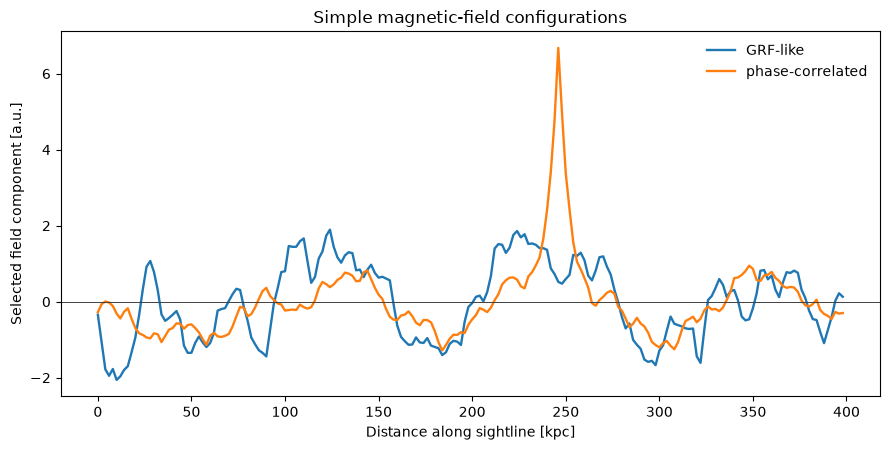

In [5]:
_ = result.plot_sightlines(index=0)


## 6. Verify the power-spectrum match

The curves should overlap. This is the crucial control: a subsequent propagation difference cannot be attributed simply to unequal one-dimensional power spectra in this synthetic construction.


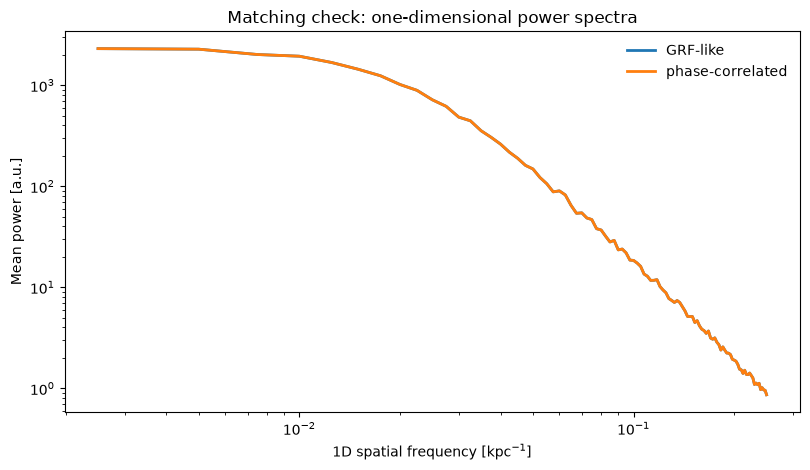

In [6]:
_ = result.plot_power_spectra()


## 7. Compare normalized propagation distributions

The dotted black curve is the analytic unit-mean exponential null, $p(x)=e^{-x}$. The step curves show the empirical normalized proxy for each field ensemble at the four configured energies.

This plot illustrates the package's intended scientific question: can phase organization or higher-order morphology leave a statistical signature after the two-point power information has been controlled?


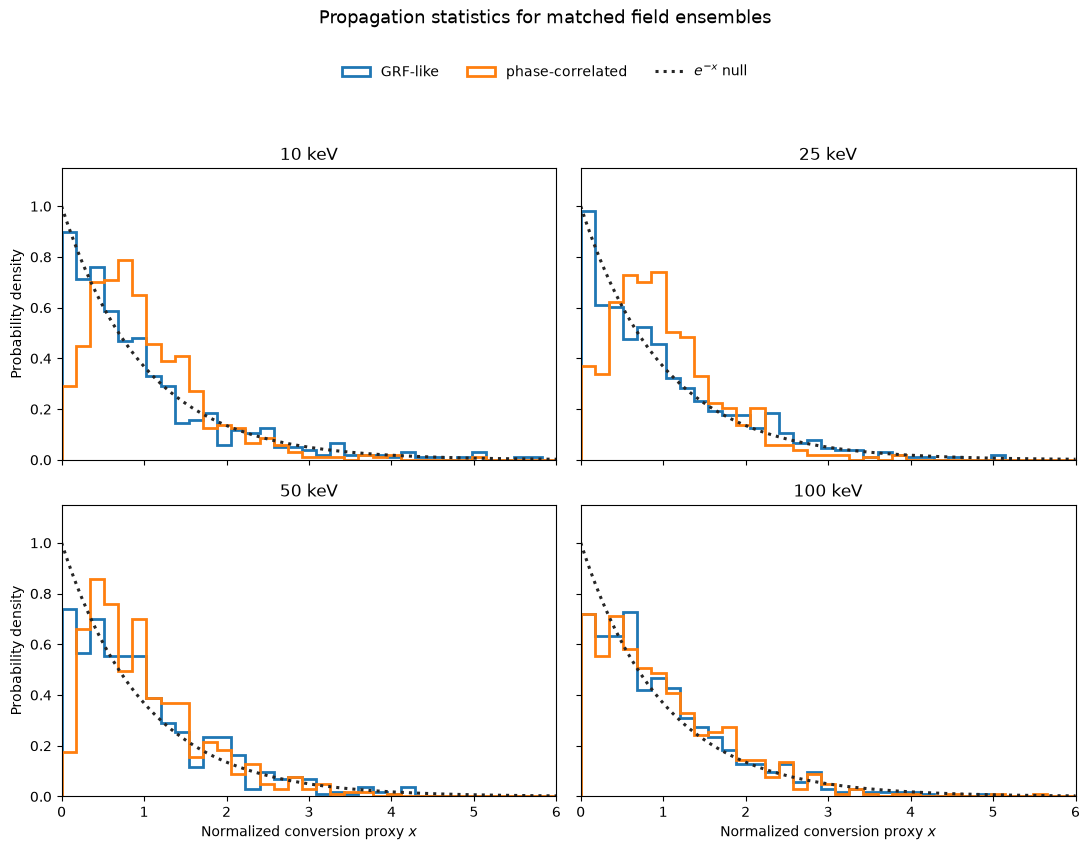

In [7]:
_ = result.plot_distributions(xmax=6.0)


## 8. Compare the high-conversion tails

A compact diagnostic is the fraction of sightlines with $x>x_0$. For $x_0=3$, the exponential-null expectation is $e^{-3}\approx0.050$.


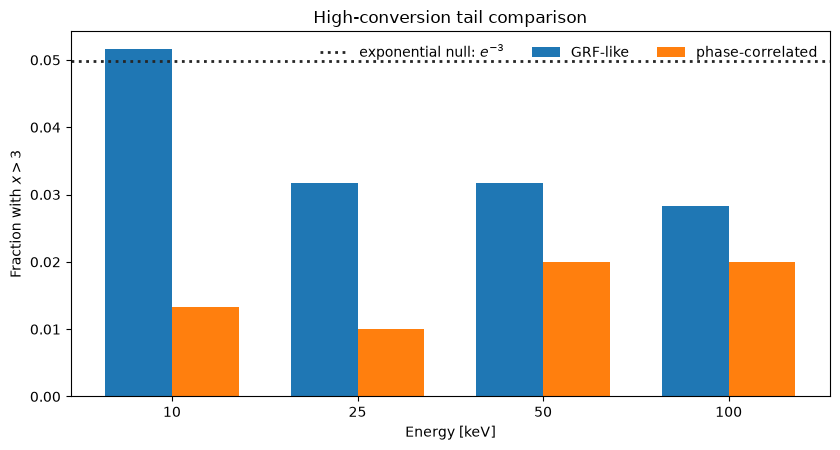

In [8]:
_ = result.plot_tail_probabilities(threshold=3.0)


## 9. Exercise

Change the threshold below from 2 to 4. Predict what will happen before running the cell: a higher threshold should produce fewer tail events.


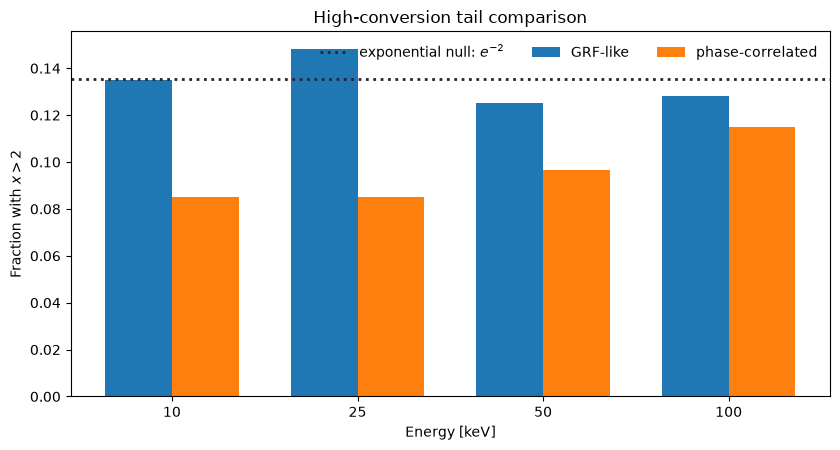

In [9]:
NEW_THRESHOLD = 2.0  # Exercise: try 4.0
_ = result.plot_tail_probabilities(threshold=NEW_THRESHOLD)


## Takeaway and limitations

The notebook's complete working pattern is:

```python
config = logalp.BenchmarkConfig.baseline()
fields = logalp.make_demo_fields(config)
result = logalp.compare(fields, config)
result.plot_distributions()
```

The demonstration fields and plots are real package features. The current propagation proxy is intentionally simple. Later releases will retain this user-facing pattern while adding validated physical phase conventions, independent perturbative and numerical solvers, user-supplied HDF5/NPZ sightlines, matched-GRF diagnostics, provenance, and uncertainty estimates.

**Common pitfall:** a direct difference between arbitrary MHD and GRF inputs may come from unequal RMS strength or power. Inspect matching diagnostics before interpreting morphology.
